# 02 · Pipeline de datos y modelado

En este cuaderno construimos el pipeline de datos y entrenamos los modelos de
clasificación. Partimos del análisis del cuaderno anterior (`01_eda.ipynb`), del que
conocemos: el desbalance de clases, las características de intensidad de las imágenes, la
presencia de ruido de etiquetado (duplicados con clases contradictorias) y la necesidad de
normalizar según ImageNet.

Comparamos tres enfoques, de menor a mayor sofisticación:

1. Una **CNN entrenada desde cero**, como línea base de referencia.
2. **ResNet50** preentrenada en ImageNet (feature extraction → fine-tuning).
3. **EfficientNetB0** preentrenada (feature extraction → fine-tuning), backbone más eficiente.

La lógica reutilizable (carga, transformaciones, modelos, entrenamiento, visualización) está
en el paquete `src/`; este cuaderno la orquesta. La métrica principal es el **F1 macro**, no
la accuracy, por el desbalance de clases identificado en el EDA.

## 0. Configuración

Importamos la lógica del proyecto desde `src/` y seleccionamos el dispositivo (GPU si está disponible).

In [1]:
import sys
sys.path.insert(0, "..")          # permite importar el paquete src/

import torch
import torch.nn as nn

from src.data import (cargar_y_limpiar, dividir_estratificado,
                      construir_transforms, crear_dataloaders, NOMBRES_CLASES)
from src.models import (CNNBaseline, construir_resnet50, descongelar_resnet,
                        construir_efficientnet_b0, descongelar_efficientnet)
from src.training import calcular_pesos, evaluar, entrenar
from src.visualization import graficar_historial, matriz_confusion

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", dispositivo)

Dispositivo: cuda


## 1. Carga, limpieza y partición de los datos

Cargamos el dataset y eliminamos las imágenes duplicadas detectadas en el EDA; esto evita además la fuga de datos que se daría si copias de una misma imagen cayeran en
particiones distintas.

A continuación dividimos en entrenamiento (70 %), validación (15 %) y test (15 %) de forma
**estratificada**, conservando la proporción de cada clase en los tres subconjuntos —
importante por el desbalance, para que las clases minoritarias estén representadas de forma
fiable también en validación y test.

In [2]:
RUTA = "../data/raw/Galaxy10_DECals.h5"

imagenes, clases = cargar_y_limpiar(RUTA)
print(f"Imágenes tras eliminar duplicados: {len(imagenes)}")

idx_train, idx_val, idx_test = dividir_estratificado(clases)
print(f"Train: {len(idx_train)}  Val: {len(idx_val)}  Test: {len(idx_test)}")

Imágenes tras eliminar duplicados: 17615
Train: 12329  Val: 2643  Test: 2643


## 2. Transformaciones, DataLoaders y pesos de clase

Definimos dos tuberías de transformación. Ambas redimensionan a 224×224 (tamaño que esperan
los backbones) y normalizan con las constantes de ImageNet. La diferencia es el **aumento de
datos** (*augmentation*), que aplicamos **solo en entrenamiento**: rotaciones aleatorias y
espejos. Son transformaciones que **preservan la clase** (las galaxias no tienen orientación
canónica ni cambian de tipo al reflejarse), a diferencia de otras que descartamos a propósito
por alterar la morfología (deformar la relación de aspecto confundiría las clases suaves
2/3/4; cambiar el color falsearía las bandas físicas g, r, z). En validación y test no se
aplica augmentation: la evaluación debe ser determinista.

Para el desbalance, calculamos **pesos por clase** que penalizan más los errores en las
clases minoritarias, y los pasamos a la función de pérdida.

In [3]:
transform_train, transform_eval = construir_transforms(tam=224)

dl_train, dl_val, dl_test = crear_dataloaders(
    imagenes, clases, idx_train, idx_val, idx_test,
    transform_train, transform_eval, batch=32)

pesos = calcular_pesos(clases, idx_train, dispositivo)
criterio = nn.CrossEntropyLoss(weight=pesos)

In [4]:
# Comprobación de cordura: inspeccionamos un lote de entrenamiento.
imgs, labs = next(iter(dl_train))
print("Lote de imágenes:", tuple(imgs.shape), imgs.dtype)
print("Lote de etiquetas:", tuple(labs.shape), labs.dtype)
print("Rango de valores:", round(imgs.min().item(), 2), "a", round(imgs.max().item(), 2))

Lote de imágenes: (32, 3, 224, 224) torch.float32
Lote de etiquetas: (32,) torch.int64
Rango de valores: -2.12 a 2.64


## 3. Modelo base (CNN entrenada desde cero)

Entrenamos una CNN sencilla desde cero como **línea base**. Su propósito no es competir, sino
aportar un punto de comparación que permita cuantificar cuánto aporta el Transfer Learning.
Parte de pesos aleatorios y solo dispone de las imágenes de entrenamiento del dataset.

In [5]:
modelo_base = CNNBaseline(num_clases=10).to(dispositivo)
n_params = sum(p.numel() for p in modelo_base.parameters())
print(f"Parámetros entrenables: {n_params:,}")

hist_base = entrenar(modelo_base, dl_train, dl_val, criterio, dispositivo,
                     epocas=8, lr=1e-3, etiqueta="baseline")

Parámetros entrenables: 12,939,722
Época  1 | loss 1.963 | F1 val 0.317 | acc val 0.357
Época  2 | loss 1.552 | F1 val 0.502 | acc val 0.518
Época  3 | loss 1.397 | F1 val 0.494 | acc val 0.522
Época  4 | loss 1.304 | F1 val 0.559 | acc val 0.599
Época  5 | loss 1.230 | F1 val 0.600 | acc val 0.631
Época  6 | loss 1.183 | F1 val 0.610 | acc val 0.635
Época  7 | loss 1.146 | F1 val 0.603 | acc val 0.637
Época  8 | loss 1.106 | F1 val 0.642 | acc val 0.666


### Conclusiones del modelo base

La CNN entrenada desde cero alcanza un F1 macro de validación de aproximadamente **0,61**.
Es un punto de partida razonable para un modelo sin preentrenar y con pocos datos, pero se
queda lejos de lo que conseguiremos con Transfer Learning. Nos sirve como referencia honesta:
cualquier backbone preentrenado debería superarla con claridad. (El valor puede variar
ligeramente entre ejecuciones, ya que el entrenamiento no fija una semilla aleatoria.)

## 4. Transfer Learning: ResNet50

Usamos ResNet50 preentrenada en ImageNet. En esta primera fase (**feature extraction**)
congelamos todo el backbone y sustituimos su capa final por una nueva de 10 salidas: solo se
entrena esa cabeza, reutilizando las características visuales ya aprendidas.

In [6]:
modelo_resnet = construir_resnet50(num_clases=10, dispositivo=dispositivo)
hist_resnet = entrenar(modelo_resnet, dl_train, dl_val, criterio, dispositivo,
                       epocas=12, lr=1e-3, etiqueta="resnet50_fase1")

Época  1 | loss 1.836 | F1 val 0.378 | acc val 0.406
Época  2 | loss 1.578 | F1 val 0.448 | acc val 0.482
Época  3 | loss 1.494 | F1 val 0.455 | acc val 0.481
Época  4 | loss 1.449 | F1 val 0.475 | acc val 0.498
Época  5 | loss 1.413 | F1 val 0.462 | acc val 0.490
Época  6 | loss 1.391 | F1 val 0.483 | acc val 0.509
Época  7 | loss 1.374 | F1 val 0.478 | acc val 0.506
Época  8 | loss 1.361 | F1 val 0.493 | acc val 0.518
Época  9 | loss 1.361 | F1 val 0.492 | acc val 0.513
Época 10 | loss 1.350 | F1 val 0.481 | acc val 0.507
Época 11 | loss 1.335 | F1 val 0.478 | acc val 0.508
Época 12 | loss 1.303 | F1 val 0.500 | acc val 0.521


### Conclusiones de ResNet50 (feature extraction)

Con el backbone congelado, ResNet50 rinde de forma modesta, en un nivel por debajo del modelo base. El resultado, lejos de ser un fallo, es revelador: las características aprendidas en 
ImageNet (fotos naturales) no se transfieren bien "tal cual" a un dominio tan
distinto como las imágenes astronómicas, tenues y de bajo contraste. Esto motiva la fase de
fine-tuning.

### 4.1 Fine-tuning de ResNet50

Segunda fase: cargamos el mejor modelo de la fase anterior, descongelamos el último bloque
convolucional (`layer4`) y reentrenamos con un learning rate mucho menor, para adaptar las
características de alto nivel al dominio de las galaxias sin destruir lo aprendido en ImageNet.

In [7]:
modelo_resnet.load_state_dict(torch.load("../models/resnet50_fase1.pt"))
descongelar_resnet(modelo_resnet)

hist_resnet_ft = entrenar(modelo_resnet, dl_train, dl_val, criterio, dispositivo,
                          epocas=20, lr=1e-4, etiqueta="resnet50_finetuning")

Época  1 | loss 1.091 | F1 val 0.625 | acc val 0.655
Época  2 | loss 0.898 | F1 val 0.663 | acc val 0.691
Época  3 | loss 0.825 | F1 val 0.685 | acc val 0.709
Época  4 | loss 0.775 | F1 val 0.686 | acc val 0.709
Época  5 | loss 0.742 | F1 val 0.701 | acc val 0.734
Época  6 | loss 0.699 | F1 val 0.704 | acc val 0.729
Época  7 | loss 0.673 | F1 val 0.694 | acc val 0.720
Época  8 | loss 0.660 | F1 val 0.722 | acc val 0.746
Época  9 | loss 0.644 | F1 val 0.732 | acc val 0.756
Época 10 | loss 0.614 | F1 val 0.728 | acc val 0.753
Época 11 | loss 0.601 | F1 val 0.741 | acc val 0.760
Época 12 | loss 0.573 | F1 val 0.726 | acc val 0.753
Época 13 | loss 0.562 | F1 val 0.738 | acc val 0.756
Época 14 | loss 0.556 | F1 val 0.754 | acc val 0.767
Época 15 | loss 0.535 | F1 val 0.737 | acc val 0.756
Época 16 | loss 0.527 | F1 val 0.751 | acc val 0.770
Época 17 | loss 0.520 | F1 val 0.729 | acc val 0.762
Época 18 | loss 0.467 | F1 val 0.762 | acc val 0.785
Época 19 | loss 0.446 | F1 val 0.759 | acc val

### 4.2 Fine-tuning extendido de ResNet50

Como segunda fase del fine-tuning, partimos del mejor modelo anterior y descongelamos también
el penúltimo bloque convolucional (`layer3`), reentrenando con un learning rate aún más bajo
(1e-5) para dar más capacidad de adaptación al dominio sin desestabilizar lo aprendido.

In [8]:
modelo_resnet.load_state_dict(torch.load("../models/resnet50_finetuning.pt"))

# Descongelar layer3 y layer4 para el fine-tuning extendido
for capa in (modelo_resnet.layer3, modelo_resnet.layer4):
    for p in capa.parameters():
        p.requires_grad = True

hist_resnet_ft2 = entrenar(modelo_resnet, dl_train, dl_val, criterio, dispositivo,
                           epocas=15, lr=1e-5, etiqueta="resnet50_finetuning_v2")

Época  1 | loss 0.431 | F1 val 0.762 | acc val 0.782
Época  2 | loss 0.415 | F1 val 0.766 | acc val 0.786
Época  3 | loss 0.391 | F1 val 0.759 | acc val 0.782
Época  4 | loss 0.379 | F1 val 0.773 | acc val 0.793
Época  5 | loss 0.363 | F1 val 0.777 | acc val 0.795
Época  6 | loss 0.359 | F1 val 0.774 | acc val 0.793
Época  7 | loss 0.351 | F1 val 0.778 | acc val 0.795
Época  8 | loss 0.336 | F1 val 0.776 | acc val 0.796
Época  9 | loss 0.323 | F1 val 0.772 | acc val 0.791
Época 10 | loss 0.332 | F1 val 0.774 | acc val 0.796
Época 11 | loss 0.307 | F1 val 0.781 | acc val 0.798
Época 12 | loss 0.303 | F1 val 0.777 | acc val 0.796
Época 13 | loss 0.303 | F1 val 0.781 | acc val 0.798
Época 14 | loss 0.293 | F1 val 0.774 | acc val 0.796
Época 15 | loss 0.288 | F1 val 0.779 | acc val 0.799


### Conclusiones del fine-tuning de ResNet50

El fine-tuning transforma el rendimiento de ResNet50 en dos pasos de descongelado creciente:

- Descongelando el último bloque (`layer4`), el F1 de validación pega un salto notable, casi 3 décimas; la mayor parte de la mejora.
- Extender el descongelado al penúltimo bloque (`layer3`) con un learning rate aún menor
  aporta una mejora adicional y lleva al modelo a su mejor resultado (≈0,78 en validación y 0,801 de accuracy en test**).

La progresión confirma la idea central: cuanto más adaptamos las capas profundas al dominio
de las galaxias, mejor, hasta converger. En un dominio visualmente alejado de ImageNet, el
feature extraction puro no basta; es el fine-tuning —y descongelar más capas— lo que
desbloquea el valor del Transfer Learning. Val y test casi coinciden, señal de buena
generalización.

## 5. Transfer Learning: EfficientNetB0

Repetimos el esquema de dos fases con un backbone más moderno y eficiente, EfficientNetB0
(~5M de parámetros frente a los ~25M de ResNet50), para comparar arquitecturas a igualdad de
procedimiento.

In [9]:
modelo_eff = construir_efficientnet_b0(num_clases=10, dispositivo=dispositivo)
hist_eff = entrenar(modelo_eff, dl_train, dl_val, criterio, dispositivo,
                    epocas=12, lr=1e-3, etiqueta="efficientnet_fase1")

Época  1 | loss 1.986 | F1 val 0.289 | acc val 0.329
Época  2 | loss 1.813 | F1 val 0.334 | acc val 0.364
Época  3 | loss 1.773 | F1 val 0.352 | acc val 0.380
Época  4 | loss 1.747 | F1 val 0.345 | acc val 0.381
Época  5 | loss 1.758 | F1 val 0.345 | acc val 0.363
Época  6 | loss 1.756 | F1 val 0.341 | acc val 0.372
Época  7 | loss 1.713 | F1 val 0.350 | acc val 0.384
Época  8 | loss 1.713 | F1 val 0.358 | acc val 0.388
Época  9 | loss 1.707 | F1 val 0.349 | acc val 0.378
Época 10 | loss 1.711 | F1 val 0.354 | acc val 0.386
Época 11 | loss 1.704 | F1 val 0.379 | acc val 0.410
Época 12 | loss 1.704 | F1 val 0.375 | acc val 0.406


### 5.1 Fine-tuning de EfficientNetB0

Descongelamos los dos últimos bloques de `features` y reentrenamos con learning rate reducido,
igual que con ResNet50.

In [10]:
modelo_eff.load_state_dict(torch.load("../models/efficientnet_fase1.pt"))
descongelar_efficientnet(modelo_eff, n_bloques=2)

hist_eff_ft = entrenar(modelo_eff, dl_train, dl_val, criterio, dispositivo,
                       epocas=20, lr=1e-4, etiqueta="efficientnet_finetuning")

Época  1 | loss 1.580 | F1 val 0.450 | acc val 0.476
Época  2 | loss 1.463 | F1 val 0.465 | acc val 0.497
Época  3 | loss 1.411 | F1 val 0.473 | acc val 0.497
Época  4 | loss 1.363 | F1 val 0.500 | acc val 0.523
Época  5 | loss 1.352 | F1 val 0.518 | acc val 0.542
Época  6 | loss 1.310 | F1 val 0.514 | acc val 0.535
Época  7 | loss 1.276 | F1 val 0.510 | acc val 0.532
Época  8 | loss 1.262 | F1 val 0.523 | acc val 0.545
Época  9 | loss 1.254 | F1 val 0.528 | acc val 0.549
Época 10 | loss 1.220 | F1 val 0.537 | acc val 0.560
Época 11 | loss 1.208 | F1 val 0.533 | acc val 0.557
Época 12 | loss 1.201 | F1 val 0.550 | acc val 0.572
Época 13 | loss 1.174 | F1 val 0.555 | acc val 0.573
Época 14 | loss 1.182 | F1 val 0.563 | acc val 0.576
Época 15 | loss 1.160 | F1 val 0.565 | acc val 0.581
Época 16 | loss 1.144 | F1 val 0.560 | acc val 0.582
Época 17 | loss 1.125 | F1 val 0.570 | acc val 0.589
Época 18 | loss 1.132 | F1 val 0.566 | acc val 0.589
Época 19 | loss 1.120 | F1 val 0.568 | acc val

### Conclusiones del fine-tuning de EfficientNETB0
Al obtener este modelo unos resultados notablemente peores que el mejor modelo tras aplicar fine-tuning a ResNet50
la primera vez, decidimos ahorrar tiempo y no probar este modelo descongelando más capas.

## 6. Evaluación final y comparativa

Comparamos el F1 de validación de todas las configuraciones, seleccionamos el mejor modelo y
lo evaluamos **una sola vez** sobre el conjunto de test, que no se ha usado en ningún momento
del entrenamiento ni de la selección. Reportamos F1 macro, accuracy, informe por clase y
matriz de confusión.

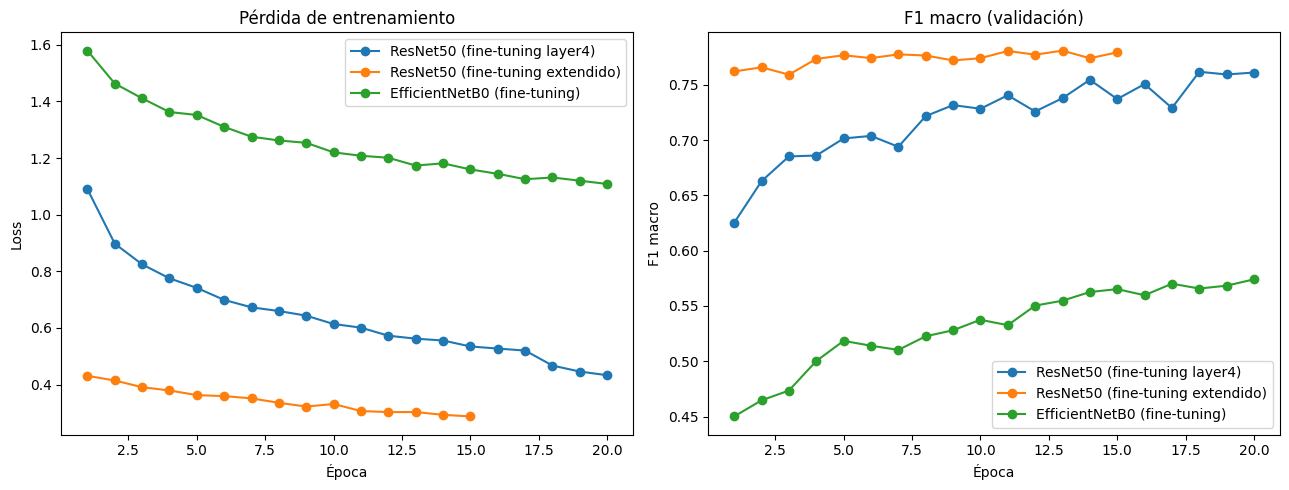

In [ ]:
graficar_historial(
    {"ResNet50 (fine-tuning layer4)": hist_resnet_ft,
     "ResNet50 (fine-tuning extendido)": hist_resnet_ft2,
     "EfficientNetB0 (fine-tuning)": hist_eff_ft},
    ruta="../reports/figures/curvas_entrenamiento.png")

In [ ]:
import pandas as pd

def mejor(historial):
    return max(r["f1_val"] for r in historial)

comparativa = pd.DataFrame({
    "Modelo": ["CNN base",
               "ResNet50 (feature extraction)",
               "ResNet50 (fine-tuning · layer4)",
               "ResNet50 (fine-tuning extendido · layer3+layer4)",
               "EfficientNetB0 (feature extraction)",
               "EfficientNetB0 (fine-tuning)"],
    "Mejor F1 val": [mejor(hist_base),
                     mejor(hist_resnet),
                     mejor(hist_resnet_ft),
                     mejor(hist_resnet_ft2),
                     mejor(hist_eff),
                     mejor(hist_eff_ft)],
}).round(3).sort_values("Mejor F1 val", ascending=False).reset_index(drop=True)
comparativa

,Modelo,Mejor F1 val
0,ResNet50 (fine-tuning extendido · layer3+layer4),0.781
1,ResNet50 (fine-tuning · layer4),0.762
2,CNN base,0.642
3,EfficientNetB0 (fine-tuning),0.574
4,ResNet50 (feature extraction),0.500
5,EfficientNetB0 (feature extraction),0.379


In [ ]:
from sklearn.metrics import classification_report

# Seleccionar el modelo ganador según la comparativa anterior.
# Por defecto, ResNet50 fine-tuning; cambiar a modelo_eff / efficientnet_finetuning.pt si gana.
mejor_modelo = modelo_resnet
mejor_pt = "../models/resnet50_finetuning_v2.pt"


mejor_modelo.load_state_dict(torch.load(mejor_pt))
f1_test, acc_test, y_true, y_pred = evaluar(mejor_modelo, dl_test, dispositivo)
print(f"F1 macro test: {f1_test:.3f}")
print(f"Accuracy test: {acc_test:.3f}\n")
print(classification_report(y_true, y_pred, target_names=NOMBRES_CLASES, digits=3))

F1 macro test: 0.786
Accuracy test: 0.801

                         precision    recall  f1-score   support

              Disturbed      0.491     0.519     0.505       158
                Merging      0.850     0.844     0.847       276
           Round Smooth      0.870     0.914     0.891       395
In-between Round Smooth      0.885     0.891     0.888       303
    Cigar Shaped Smooth      0.672     0.820     0.739        50
          Barred Spiral      0.799     0.765     0.781       306
  Unbarred Tight Spiral      0.657     0.780     0.714       273
  Unbarred Loose Spiral      0.741     0.617     0.673       389
  Edge-on without Bulge      0.895     0.920     0.907       213
     Edge-on with Bulge      0.950     0.886     0.917       280

               accuracy                          0.801      2643
              macro avg      0.781     0.796     0.786      2643
           weighted avg      0.805     0.801     0.801      2643



### Resultados en test

El mejor modelo (ResNet50 con fine-tuning extendido) se evalúa una única vez sobre el conjunto
de test, no usado en ningún momento del entrenamiento ni de la selección de modelos. Obtiene
**F1 macro 0,787** y **accuracy 0,801**, prácticamente idéntico a su rendimiento en validación,
lo que indica **buena generalización y ausencia de sobreajuste**.

El comportamiento por clase revela patrones coherentes con la naturaleza del problema:

- **Las galaxias "de canto" son las mejor clasificadas** (Edge-on without Bulge F1 ≈ 0,91;
  with Bulge ≈ 0,91). Su morfología —una línea fina, con o sin bulbo— es inconfundible.

- **Las suaves se reconocen muy bien** (Round Smooth F1 ≈ 0,889; In-between ≈ 0,890). La
  confusión apreciable es entre ellas (redonda ↔ intermedia), esperable porque representan un
  continuo de achatamiento más que categorías nítidas.

- **La clase minoritaria "Cigar Shaped" se recupera con éxito** (recall ≈ 0,800 pese a tener
  solo 50 imágenes en test), aunque con precisión más baja ≈ (0,73): el modelo la detecta casi
  siempre, a costa de algún falso positivo. Es la prueba de que la ponderación por clase cumplió
  su función; sin ella, el modelo habría tendido a ignorarla.

- **Las espirales no barradas son la principal fuente de error** (Unbarred Loose F1 ≈ 0,660;
  Unbarred Tight ≈ 0,709). Se confunden entre sí y con la barrada (Barred Spiral ≈ 0,780): las
  tres clases de espiral comparten rasgos muy similares y distinguirlas exige detectar detalles
  finos (presencia de barra, grado de enrollamiento) que a menudo se pierden a esta resolución.

- **"Disturbed" es la clase más difícil** (F1 ≈ 0,5), con errores repartidos hacia muchas
  otras clases. Es coherente con su naturaleza: es la categoría morfológicamente más ambigua y
  subjetiva, y donde el etiquetado por consenso es menos fiable (de ahí provenían los duplicados
  con etiquetas contradictorias detectados en el EDA).

En conjunto, los aciertos y errores **no son aleatorios**: el modelo destaca en las morfologías
visualmente distintivas y falla en las clases intrínsecamente ambiguas, exactamente como se
anticipó en el análisis exploratorio.

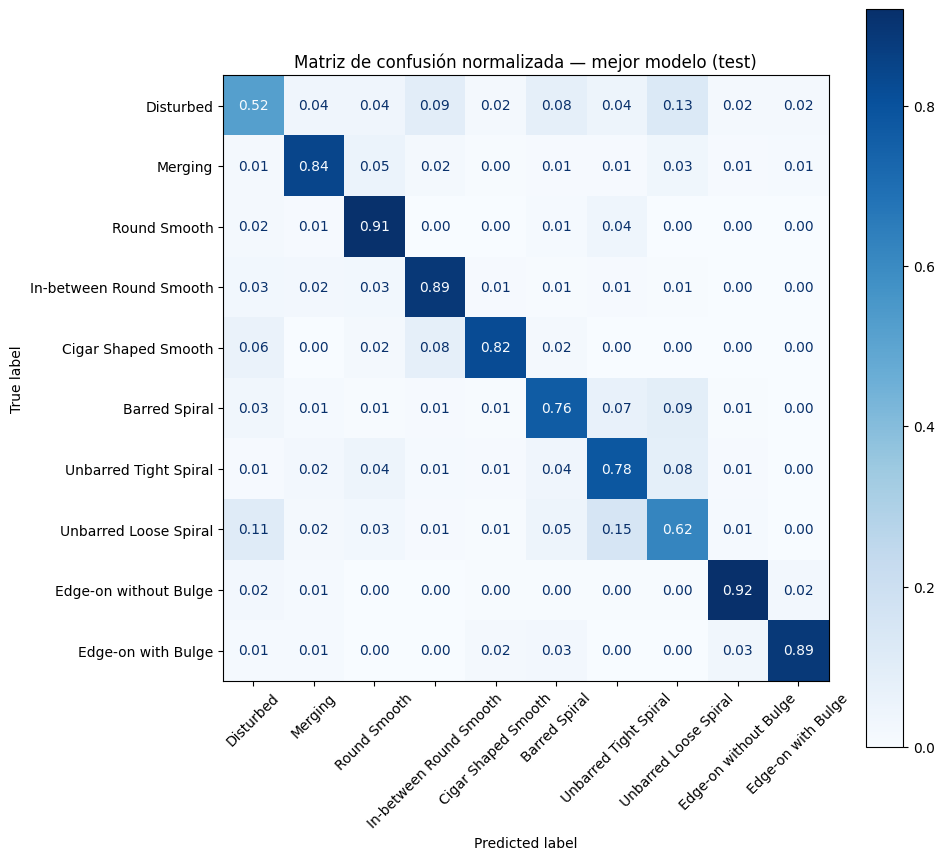

In [ ]:
matriz_confusion(y_true, y_pred, NOMBRES_CLASES,
                 ruta="../reports/figures/matriz_confusion.png",
                 titulo="Matriz de confusión normalizada — mejor modelo (test)")

## 7. Conclusiones generales

- **El Transfer Learning con fine-tuning es la mejor estrategia.** El mejor modelo (ResNet50
  con fine-tuning extendido) alcanza un F1 macro de 0,787 y una accuracy de 0,801 en test,
  muy por encima de la CNN entrenada desde cero (F1 0,614). El experimento muestra además un
  matiz interesante: en un dominio visualmente alejado de ImageNet, **congelar el backbone no
  basta** (el feature extraction puro rindió solo 0,504 (aprox), por debajo incluso de la CNN base);
  es la **adaptación progresiva de las capas profundas** lo que aporta el salto de rendimiento.

- **El descongelado progresivo mejora el resultado.** Se observa una mejora sostenida al
  descongelar más capas de ResNet50: feature extraction (0,504 aprox) → fine-tuning de `layer4`
  (0,756) → fine-tuning extendido de `layer3`+`layer4` (~0,78). Cuanto más adaptamos el modelo
  al dominio de las galaxias, mejor, hasta converger.

- **Los errores del modelo coinciden con lo anticipado en el EDA.** Las espirales (barrada,
  apretada y abierta) se confunden entre sí por su gran similitud visual; las galaxias "de
  canto" se clasifican muy bien por ser morfológicamente inconfundibles; y la clase "Disturbed"
  es la más difícil, coherente con su ambigüedad intrínseca y con el ruido de etiquetado
  detectado en el EDA. El análisis exploratorio predijo qué sería fácil y qué difícil, y los
  resultados lo confirmaron.

- **La gestión del desbalance funciona.** Gracias a los pesos por clase, la clase minoritaria
  "Cigar Shaped" (solo ~50 imágenes en test) se reconoce muy bien (recall entre 0.8 y 0.9), cuando un
  modelo sin esa corrección habría tendido a ignorarla.

- **EfficientNetB0 quedó por debajo de ResNet50** a igualdad de procedimiento (F1 0,573 frente
  a ~0,76). Con un dataset reducido y solo dos bloques descongelados, su arquitectura más
  compacta adaptó menos capacidad al dominio que el último bloque (mucho mayor) de ResNet50.
  Por ese motivo, el fine-tuning extendido se aplicó solo al backbone más prometedor.

- **Parte de la dificultad es intrínseca al dataset**, no del modelo: ambigüedad morfológica
  real entre clases vecinas, efecto de selección por distancia (redshift) observado en el EDA,
  y etiquetas obtenidas por consenso de voluntarios sobre casos límite.

- **Trabajo futuro:** explorar arquitecturas que incorporan la invariancia rotacional de forma
  nativa (CNN equivariantes / GCNN, que sostienen el estado del arte en este dataset), mayor
  resolución de entrada, y técnicas adicionales de balanceo.